# Mini Batch Gradient Descent

## Code

In [2]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
X,y = load_diabetes(return_X_y=True)
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [3]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
reg = LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [4]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [5]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568969

In [22]:
import random 

class MBGDRegressor:

    def __init__(self, batch_size, learning_rate=0.01, epochs=100):

        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size

    def fit(self,X_train,y_train):

        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):
            for j in range(int(X_train.shape[0]/self.batch_size)):

                idx = random.sample(range(X_train.shape[0]),self.batch_size)
                
                y_hat = np.dot(X_train[idx],self.coef_) + self.intercept_

                #print("Shape of y_hat",y_hat.shape)

                intercept_der = -2 * np.mean(y_train[idx] - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)

                coef_der = -2 * np.mean((y_train[idx] - y_hat).reshape(-1,1) * X_train[idx], axis=0)
                self.coef_ = self.coef_ - (self.lr * coef_der)

            print(self.intercept_,self.coef_)

    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_


In [23]:
mbr = MBGDRegressor(batch_size=int(X_train.shape[0]/50),learning_rate=0.01,epochs=100)
mbr.fit(X_train,y_train)

92.59703309305208 [1.83120377 1.09990001 2.8505459  2.41607283 2.24463395 1.98135074
 0.27272824 2.15590234 3.03522411 1.74057254]
124.80807435158955 [ 2.7240716   0.84496716  4.47521056  3.72051414  2.74172182  2.38057618
 -0.97790827  3.32446305  4.85671664  2.3293084 ]
144.27694082718867 [ 3.36094255  1.01404494  6.53866059  5.42405989  3.34630837  2.91941852
 -2.56922293  4.89248493  7.03166266  3.5535735 ]
146.43047096667067 [ 4.42679715  1.07830658  8.42943091  6.81786808  4.06942754  3.51015028
 -3.84059272  6.33396229  8.94787274  4.57558335]
145.85981608410233 [ 5.2531241   1.07951182 10.18770223  8.39527169  4.48394711  3.74037081
 -4.97645934  7.4568011  10.76561585  5.74863319]
147.85377577363113 [ 5.98195993  1.10029407 12.18414899  9.66029886  5.09933777  4.24340141
 -6.38484404  8.89959385 12.67544569  6.61147242]
144.36230063354404 [ 6.67875206  1.33645729 14.19698014 11.20425202  5.90648288  4.90925413
 -7.67012314 10.33730359 14.70146022  7.74993012]
146.2383591395779

In [24]:
y_pred = mbr.predict(X_test)
r2_score(y_test,y_pred)

0.31817757352821086

## using Sklearn

In [25]:
from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor(learning_rate='constant',eta0=0.1)
batch_size = 35

for i in range(100):
    
    idx = random.sample(range(X_train.shape[0]),batch_size)
    sgd.partial_fit(X_train[idx],y_train[idx])

In [26]:
sgd.coef_

array([  69.90588415,  -72.83946856,  342.72034682,  248.08273342,
         14.26830232,  -29.08131122, -189.00585422,  137.38571772,
        324.86193805,  105.79448715])

In [27]:
sgd.intercept_

array([157.06606004])

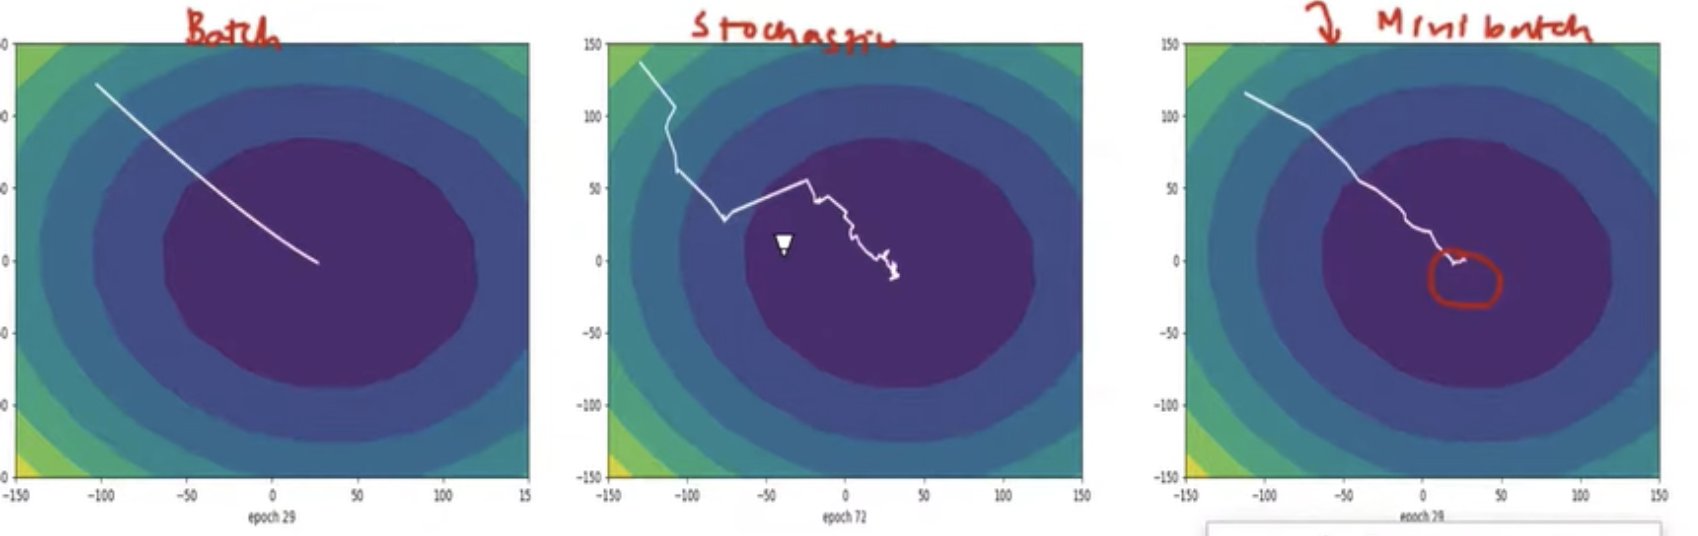